In [103]:
# ============================================
# scRNA-seq basic Scanpy workflow
# ============================================
#
# This notebook:
# 1. Loads 10x matrix.mtx.gz datasets
# 2. Merges 6 mtxitions
# 3. Performs preprocessing
# 4. Computes PCA + UMAP
# 5. Plots UMAP colored by mtxition
#
# Required directory structure:
#
# ============================================
# 1. Install packages (run once)
# ============================================

%pip install scanpy anndata matplotlib leidenalg

In [104]:
# ============================================
# Download data from GEO
# ============================================ 
!rm -rf data
!mkdir data
!wget "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE196280&format=file" -O GSE196280.tar
!tar -xvf GSE196280.tar --directory data/

--2026-05-20 12:34:08--  https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE196280&format=file
Resolving www.ncbi.nlm.nih.gov (www.ncbi.nlm.nih.gov)... 130.14.29.110, 2607:f220:41e:4290::110
Connecting to www.ncbi.nlm.nih.gov (www.ncbi.nlm.nih.gov)|130.14.29.110|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 119162880 (114M) [application/x-tar]
Saving to: ‘GSE196280.tar’

GSE196280.tar       100%[===================>] 113.64M   110MB/s    in 1.0s    

2026-05-20 12:34:09 (110 MB/s) - ‘GSE196280.tar’ saved [119162880/119162880]

GSM5866861_EZH2i_Naive_WT.barcodes.tsv.gz
GSM5866861_EZH2i_Naive_WT.features.tsv.gz
GSM5866861_EZH2i_Naive_WT.matrix.mtx.gz
GSM5866862_EZH2i_Naive_D2.barcodes.tsv.gz
GSM5866862_EZH2i_Naive_D2.features.tsv.gz
GSM5866862_EZH2i_Naive_D2.matrix.mtx.gz
GSM5866863_EZH2i_Naive_D4.barcodes.tsv.gz
GSM5866863_EZH2i_Naive_D4.features.tsv.gz
GSM5866863_EZH2i_Naive_D4.matrix.mtx.gz
GSM5866864_EZH2i_Naive_D7.barcodes.tsv.gz
GSM5866864_EZH2i_Naive_D7.

In [105]:

# ============================================
# 2. Imports
# ============================================

import scanpy as sc
import re
import anndata as ad
import pandas as pd
import numpy as np
from pathlib import Path


In [106]:
# Plot settings
sc.settings.verbosity = 3
sc.set_figure_params(figsize=(6, 6))

base = Path("data/")
adatas = []
#search all matrix.mtx.gz files in data/ and remove the matrix.mtx.gz suffix to get the mtxition name
for mtx in base.iterdir():
    if not mtx.is_file() or not mtx.name.endswith("matrix.mtx.gz"):
        continue

    mtxition = mtx.name.replace(".matrix.mtx.gz", "")

    #create a subdir called mtxition and move all files with the same mtxition name into it
    dir = base / mtxition
    dir.mkdir(exist_ok=True)
    for file in base.iterdir():
        if file.is_file() and file.name.startswith(mtxition):
            file.rename(dir / file.name.replace(mtxition+".", ""))


for dir in base.iterdir():
    if not dir.is_dir():
        continue

    condition = re.sub(r"GSM[^_]+_", "", dir.name)  
    print(f"Loading {condition} from {dir}...")

    adata = sc.read_10x_mtx(
        dir,
        var_names="gene_symbols",
        cache=True
    )

    # Add metadata
    adata.obs["name"] = condition

    # Make unique cell IDs
    adata.obs_names_make_unique()

    # Optional: prefix barcodes with mtxition
    adata.obs_names = [
        f"{condition}_{cell}"
        for cell in adata.obs_names
    ]

    adatas.append(adata)


Loading EZH2i_Naive_D7 from data/GSM5866864_EZH2i_Naive_D7...
... reading from cache file cache/data-GSM5866864_EZH2i_Naive_D7-matrix.h5ad
Loading EZH2i_Primed_WT from data/GSM5866865_EZH2i_Primed_WT...
... reading from cache file cache/data-GSM5866865_EZH2i_Primed_WT-matrix.h5ad
Loading EZH2i_Primed_D7 from data/GSM5866866_EZH2i_Primed_D7...
... reading from cache file cache/data-GSM5866866_EZH2i_Primed_D7-matrix.h5ad
Loading EZH2i_Naive_D2 from data/GSM5866862_EZH2i_Naive_D2...
... reading from cache file cache/data-GSM5866862_EZH2i_Naive_D2-matrix.h5ad
Loading EZH2i_Naive_D4 from data/GSM5866863_EZH2i_Naive_D4...
... reading from cache file cache/data-GSM5866863_EZH2i_Naive_D4-matrix.h5ad
Loading EZH2i_Naive_WT from data/GSM5866861_EZH2i_Naive_WT...
... reading from cache file cache/data-GSM5866861_EZH2i_Naive_WT-matrix.h5ad


In [107]:
# ============================================
# 5. Merge datasets
# ============================================
print(adatas)

adata = ad.concat(
    adatas,
    axis=0,
    join="outer",
    label="name",
    keys=[adata.obs["name"][0] for adata in adatas],
    index_unique="-"
)

print(adata)

[AnnData object with n_obs × n_vars = 2640 × 33538
    obs: 'name'
    var: 'gene_ids', 'feature_types', AnnData object with n_obs × n_vars = 2683 × 33538
    obs: 'name'
    var: 'gene_ids', 'feature_types', AnnData object with n_obs × n_vars = 2666 × 33538
    obs: 'name'
    var: 'gene_ids', 'feature_types', AnnData object with n_obs × n_vars = 2971 × 33538
    obs: 'name'
    var: 'gene_ids', 'feature_types', AnnData object with n_obs × n_vars = 2833 × 33538
    obs: 'name'
    var: 'gene_ids', 'feature_types', AnnData object with n_obs × n_vars = 2805 × 33538
    obs: 'name'
    var: 'gene_ids', 'feature_types']


/tmp/ipykernel_32998/3947174397.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  keys=[adata.obs["name"][0] for adata in adatas],


AnnData object with n_obs × n_vars = 16598 × 33538
    obs: 'name'


In [108]:
# ============================================
# 6. Basic QC metrics
# ============================================

# Mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

# View summary
adata.obs.head()


,name,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
EZH2i_Naive_D7_AAACCCATCACTTCTA-1-EZH2i_Naive_D7,EZH2i_Naive_D7,376,511.0,4.0,0.782779
EZH2i_Naive_D7_AAACCCATCGCCTATC-1-EZH2i_Naive_D7,EZH2i_Naive_D7,347,531.0,8.0,1.506591
EZH2i_Naive_D7_AAACGCTGTACTTCCC-1-EZH2i_Naive_D7,EZH2i_Naive_D7,613,1209.0,7.0,0.578991
EZH2i_Naive_D7_AAACGCTGTCAAGTTC-1-EZH2i_Naive_D7,EZH2i_Naive_D7,530,1576.0,959.0,60.850258
EZH2i_Naive_D7_AAAGAACCACCTGCAG-1-EZH2i_Naive_D7,EZH2i_Naive_D7,508,972.0,5.0,0.514403


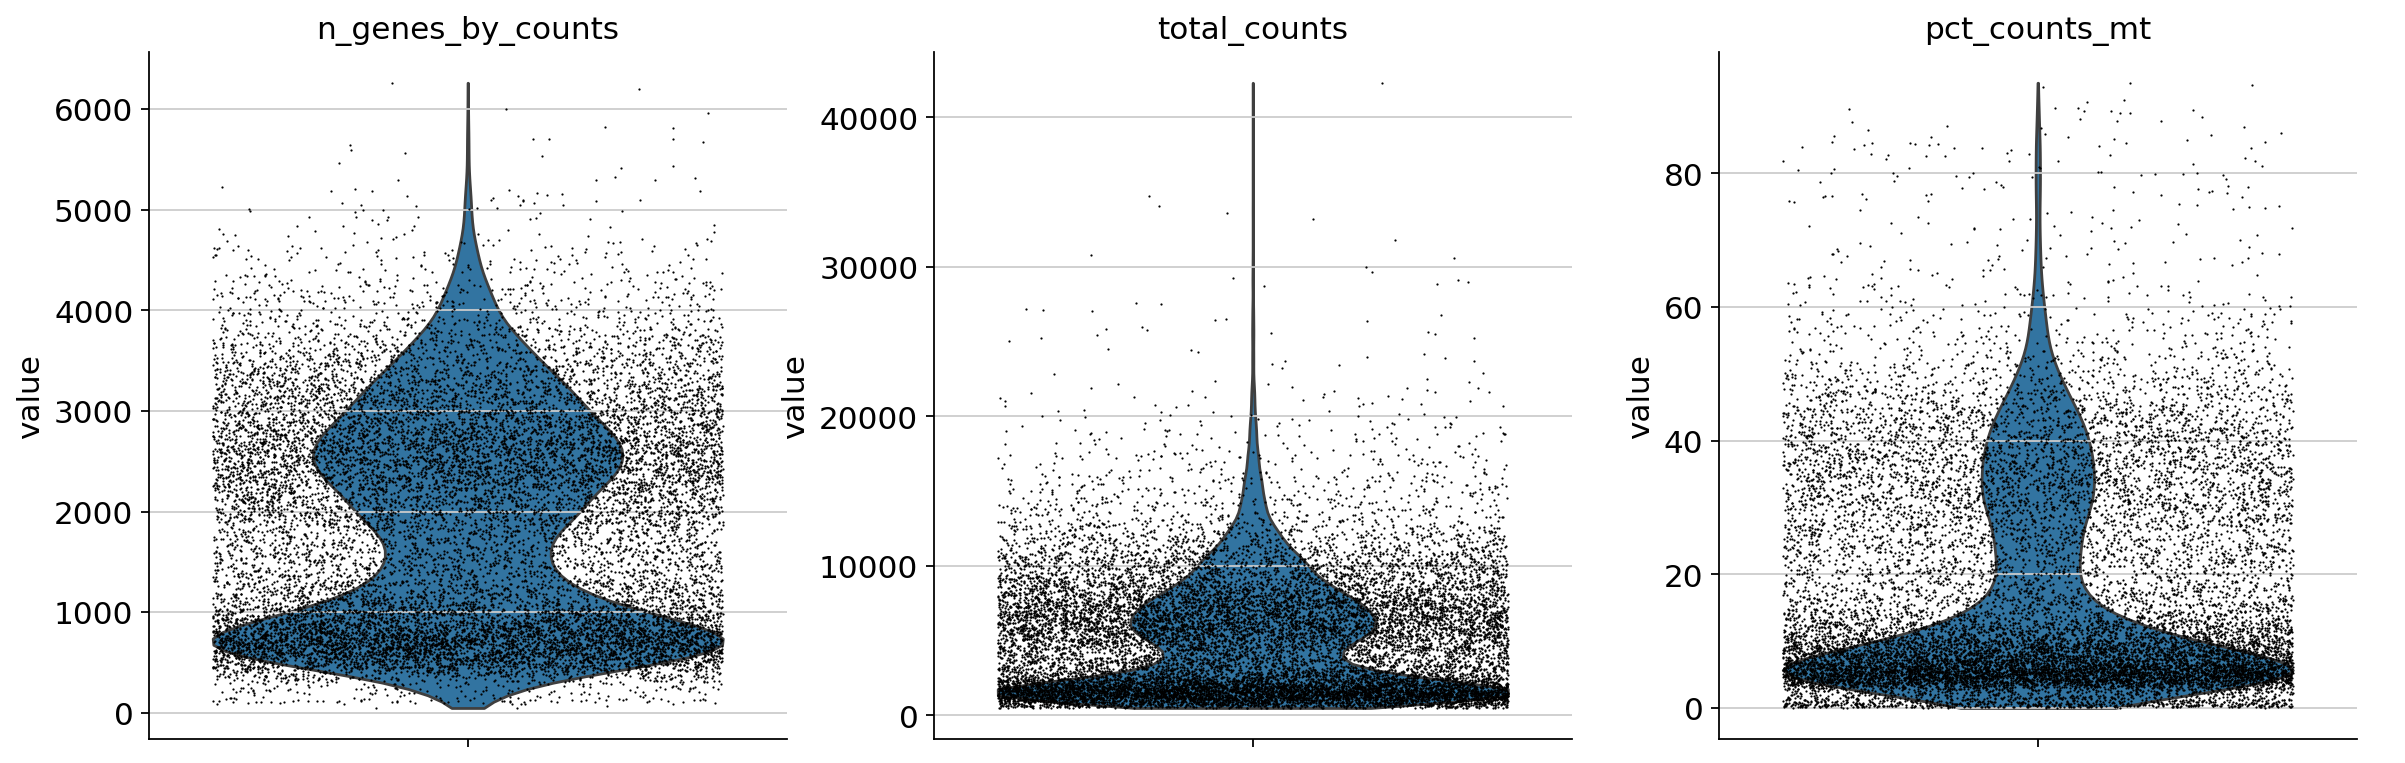

In [109]:
# ============================================
# 7. QC plots
# ============================================

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)


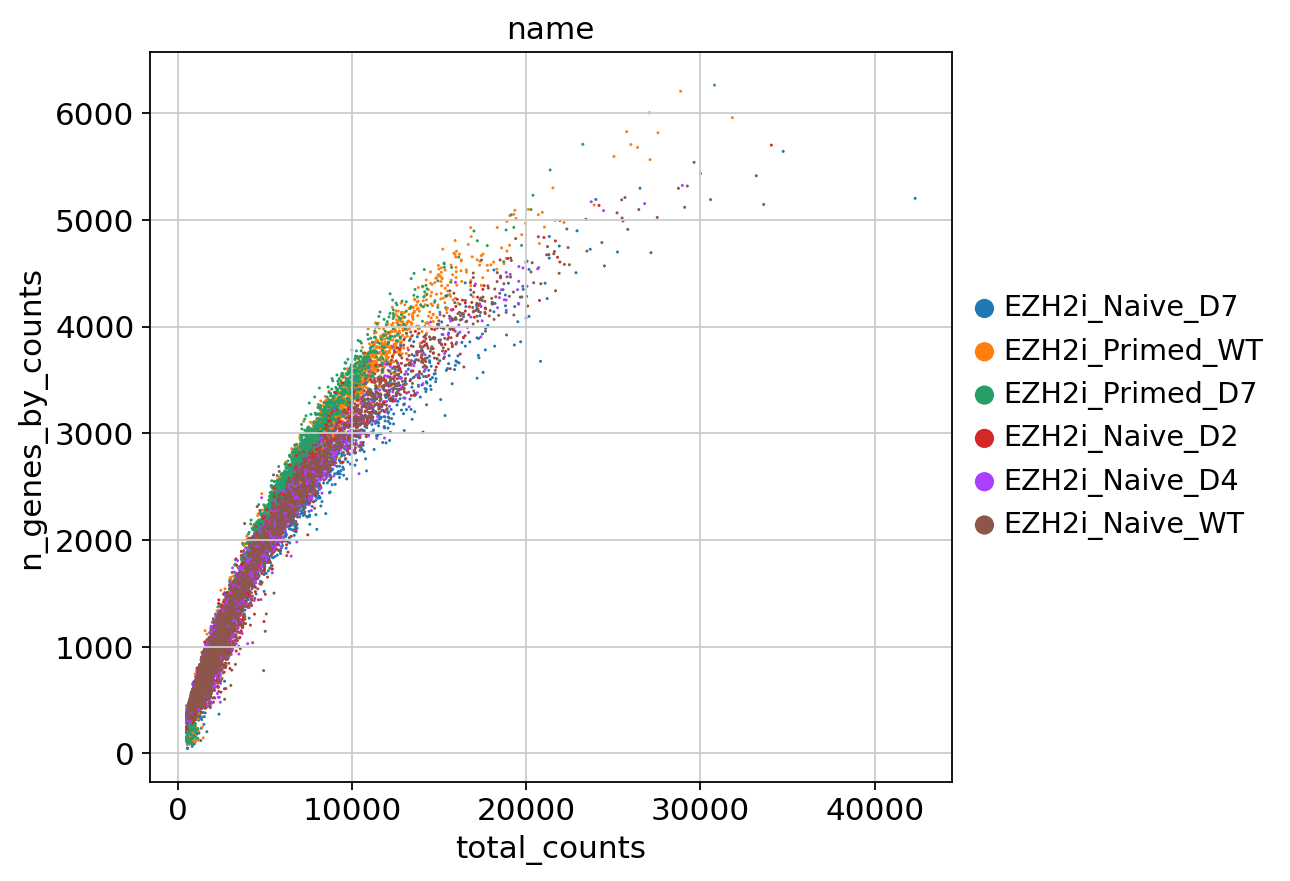

In [110]:

sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="name"
)


In [111]:
# just checking if some interesting genes are present in the dataset
marker_genes = [
    "SOX2",    
    "GATA3",  
    "TMEM88",    
    "CLDN4",
    "CD24",
    "NANOG" 
]

existing_markers = [
    g for g in marker_genes
    if g in adata.var_names
]

print(existing_markers)

['SOX2', 'GATA3', 'TMEM88', 'CLDN4', 'CD24', 'NANOG']


In [112]:

# ============================================
# 8. Filter low-quality cells/genes
# ============================================

# Filter cells
sc.pp.filter_cells(adata, min_genes=200)

# Filter genes
sc.pp.filter_genes(adata, min_cells=3)

# Remove high mitochondrial cells
adata = adata[adata.obs.pct_counts_mt < 15].copy()

print(adata)


filtered out 113 cells that have less than 200 genes expressed
filtered out 11238 genes that are detected in less than 3 cells
AnnData object with n_obs × n_vars = 9931 × 22300
    obs: 'name', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'name_colors'


In [113]:
# ============================================
# 9. Normalize and log transform
# ============================================

# Save raw counts
adata.layers["counts"] = adata.X.copy()

# Normalize counts per cell
sc.pp.normalize_total(
    adata,
    target_sum=1e4
)

# Log transform
sc.pp.log1p(adata)


normalizing counts per cell
    finished (0:00:00)


extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


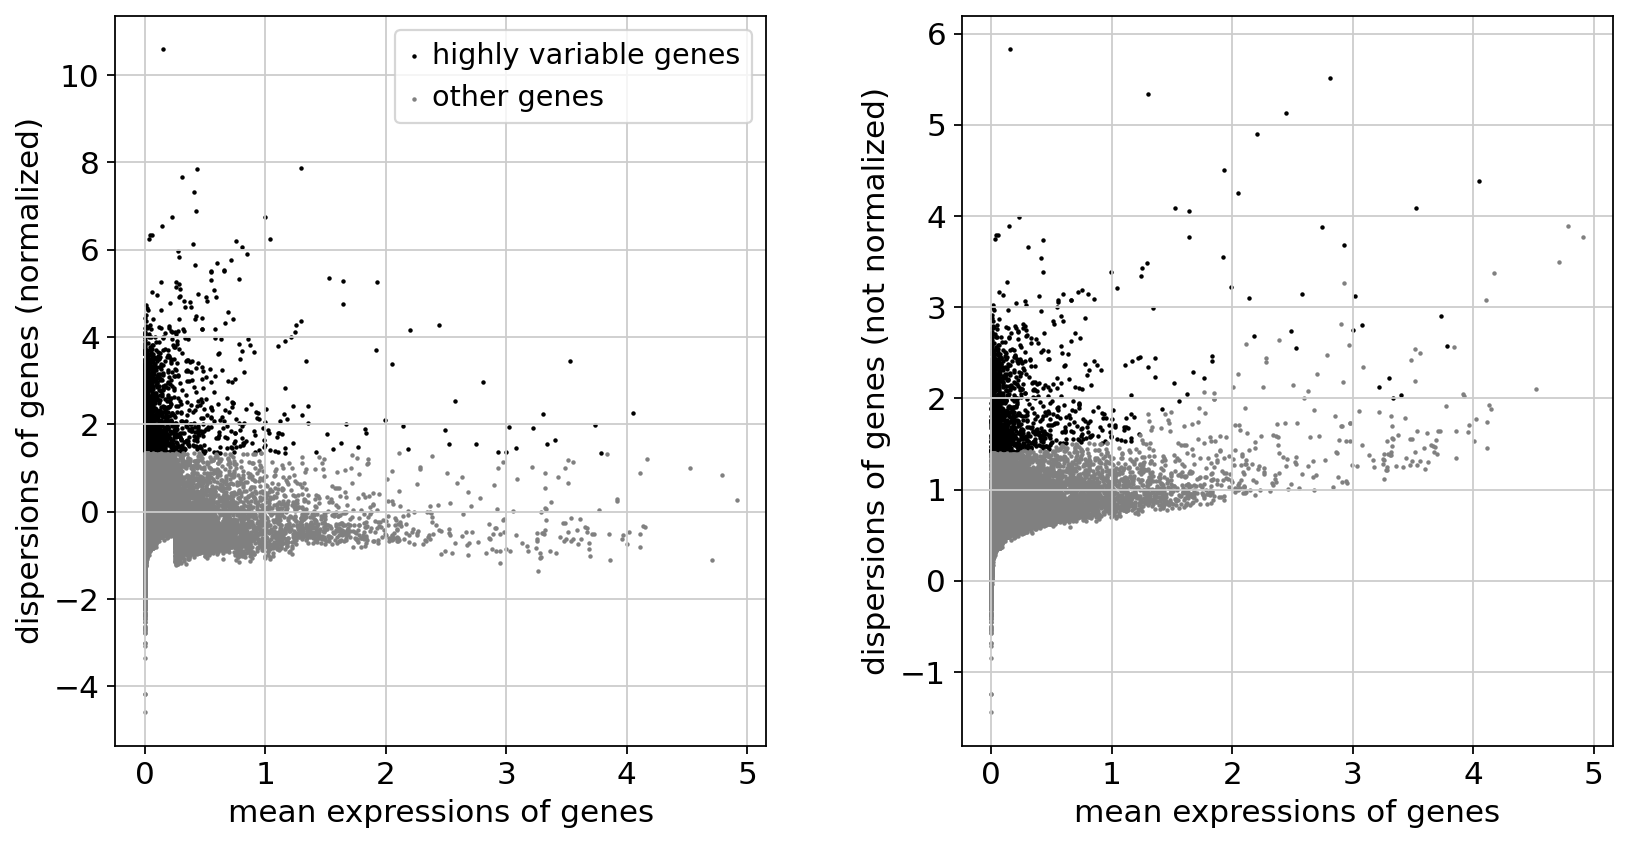

In [114]:
# ============================================
# 10. Highly variable genes
# ============================================

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    subset=False, #want to keep all the genes for later visualization
    flavor="seurat"
)

# Plot HVGs
sc.pl.highly_variable_genes(adata)

In [115]:
# ============================================
# 11. Scale data
# ============================================

sc.pp.scale(
    adata,
    max_value=10
)

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:07)


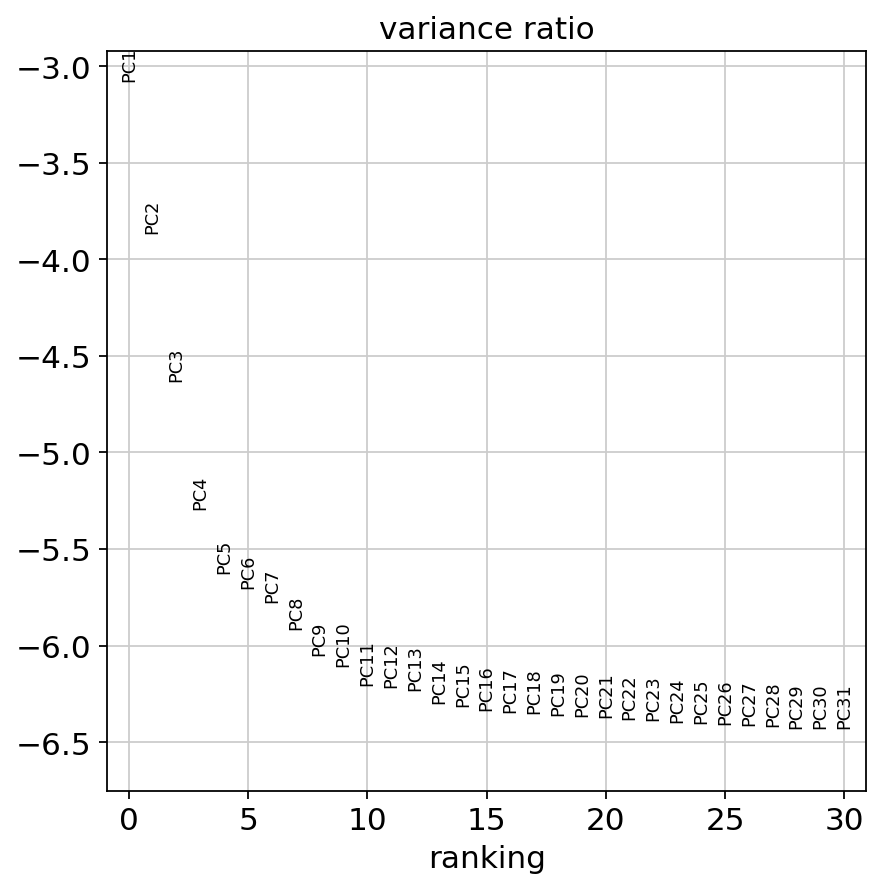

In [116]:
# ============================================
# 12. PCA
# ============================================

sc.tl.pca(
    adata,
    svd_solver="arpack"
)

# PCA variance plot
sc.pl.pca_variance_ratio(
    adata,
    log=True
)

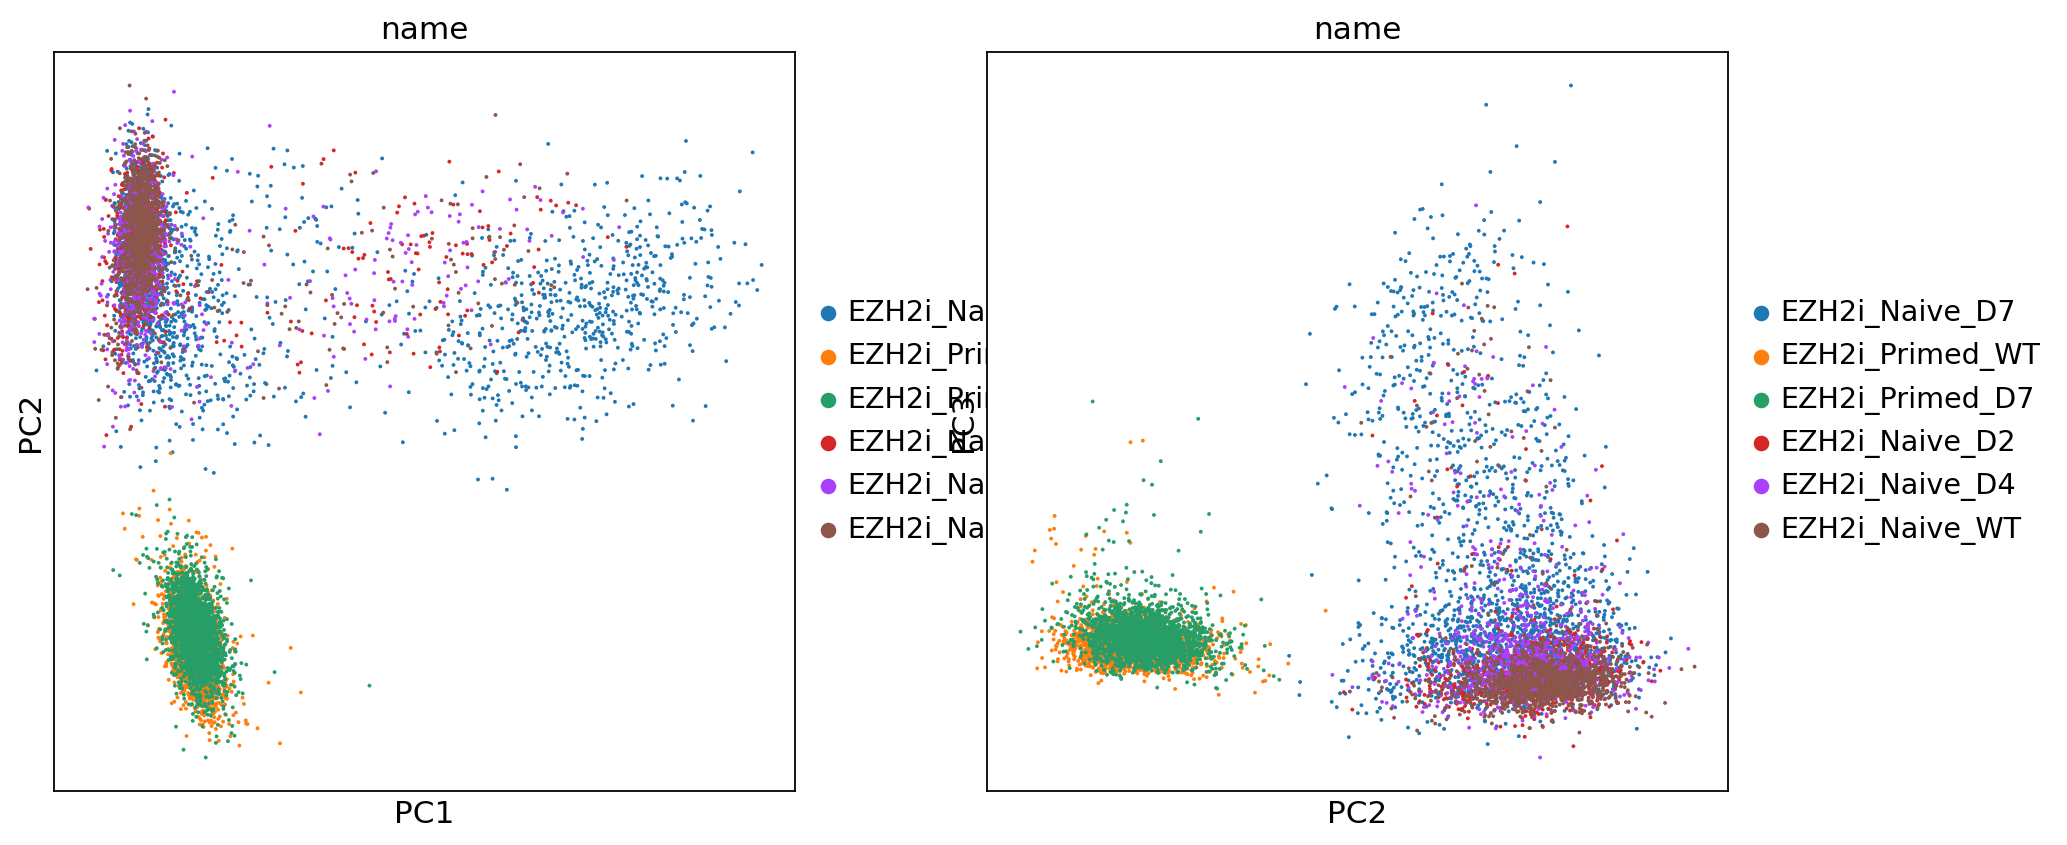

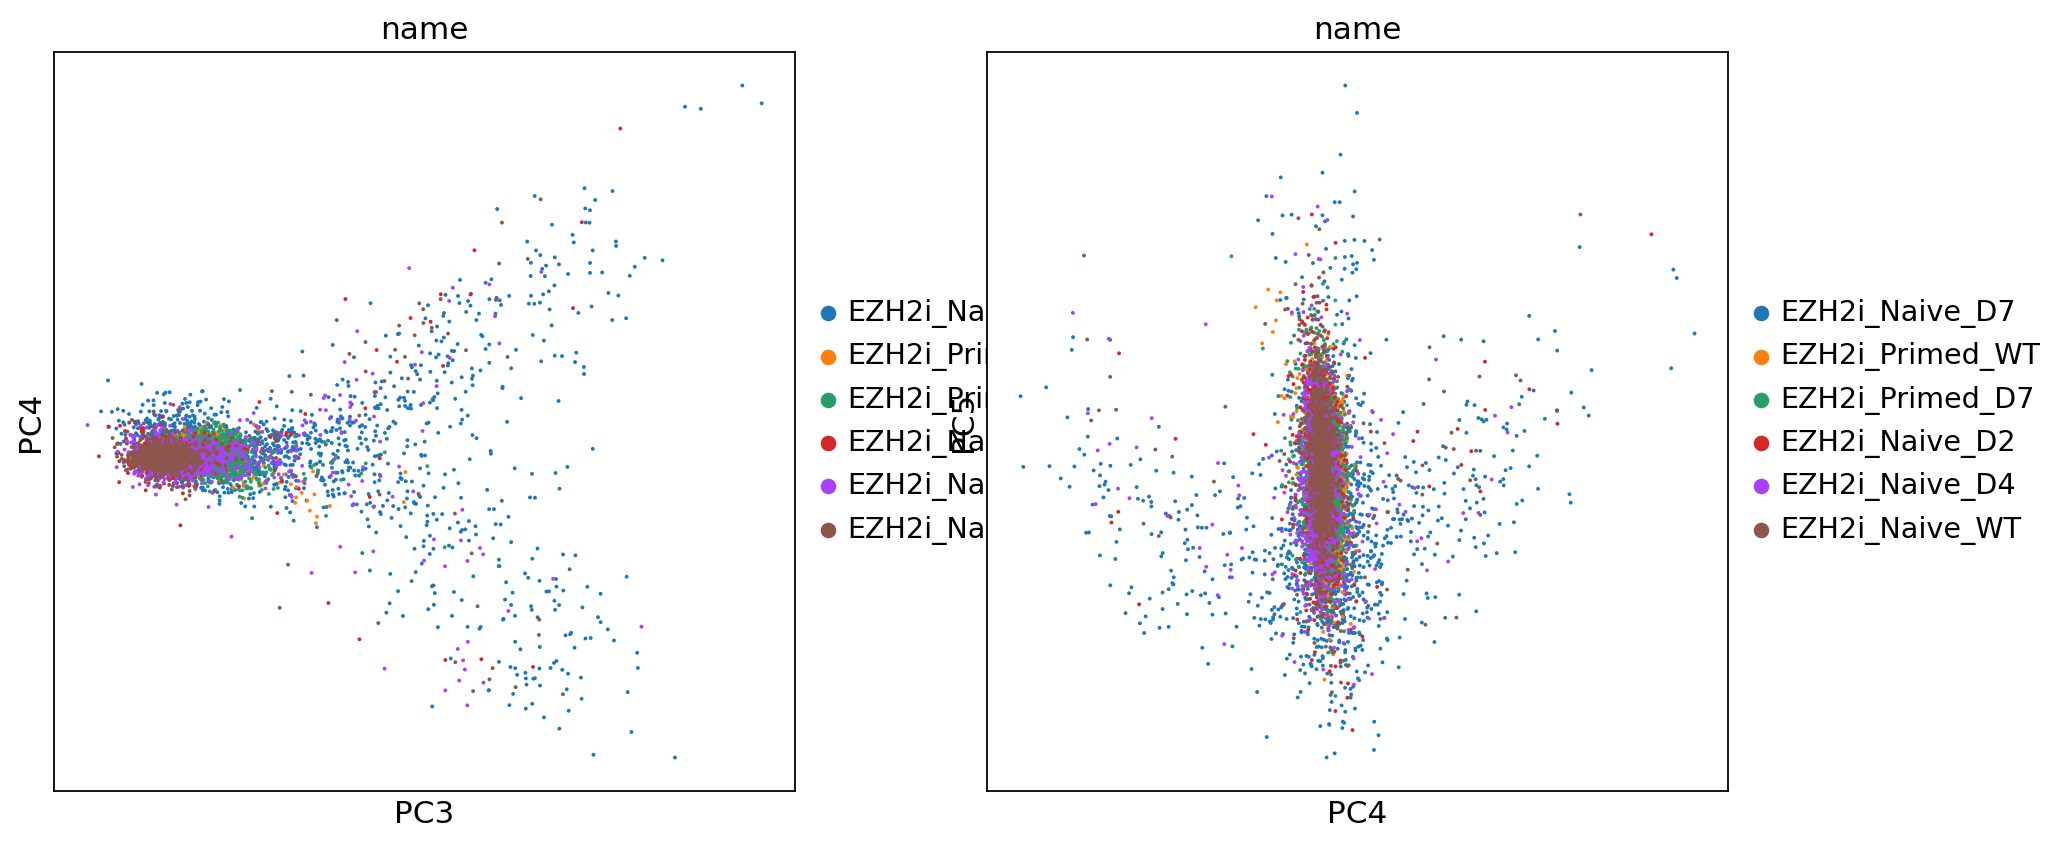

In [117]:
sc.pl.pca(
    adata,
    color="name",
    components=["1,2", "2,3"]
)

sc.pl.pca(
    adata,
    color="name",
    components=["3,4", "4,5"]
)



In [118]:
# ============================================
# 13. Compute neighbors
# ============================================

sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=30
)


# ============================================
# 14. UMAP
# ============================================

sc.tl.umap(adata)


computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:21)


In [119]:
# ============================================
# 15. Leiden clustering
# ============================================

sc.tl.leiden(
    adata,
    resolution=0.5
)

running Leiden clustering


/tmp/ipykernel_32998/1504318453.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:07)


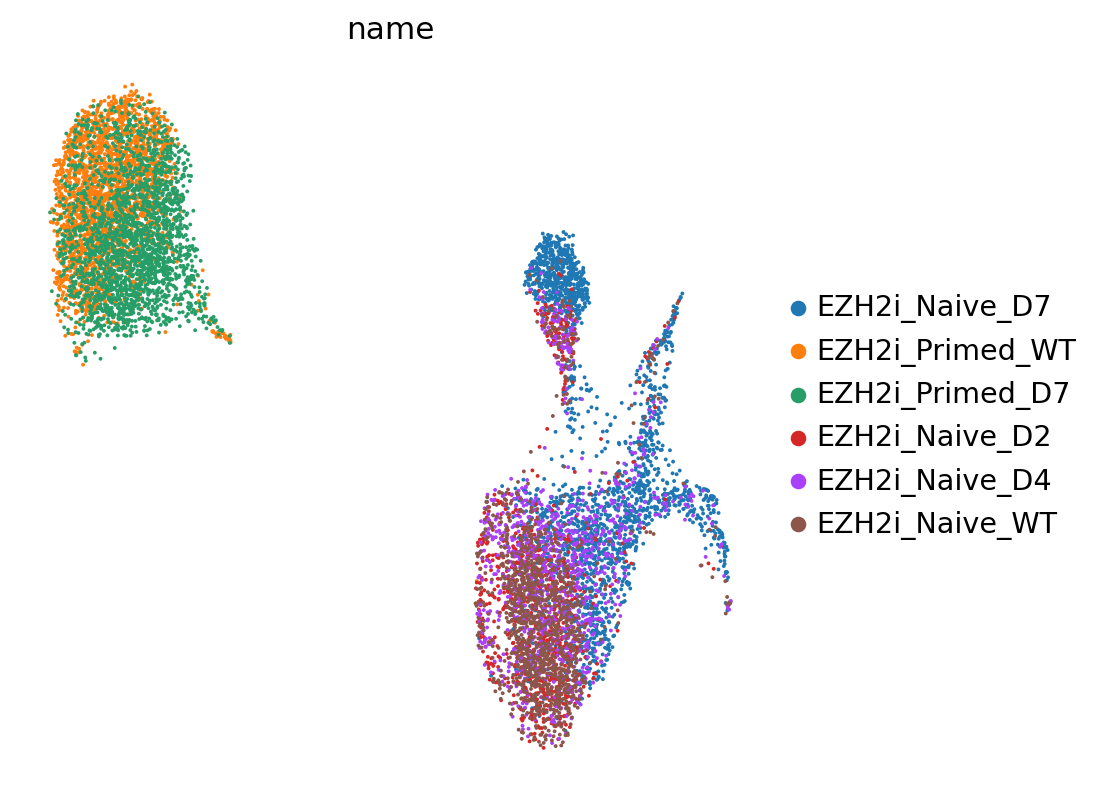

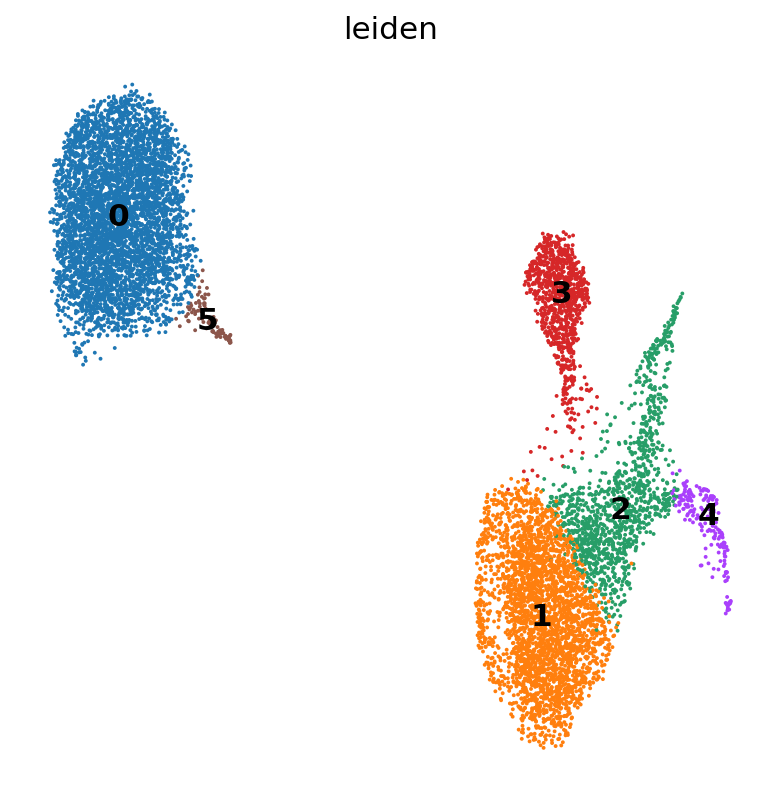

In [120]:
# ============================================
# 16. Plot UMAPs
# ============================================

# Colored by mtxition
sc.pl.umap(
    adata,
    color="name",
    frameon=False
)

# Colored by cluster
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    frameon=False
)

['SOX2', 'NANOG', 'GATA3', 'CLDN4', 'TP63', 'TMEM88', 'KRT18', 'TBX3', 'CDX1', 'CDX2', 'TFAP2A', 'TFAP2C', 'CD24']


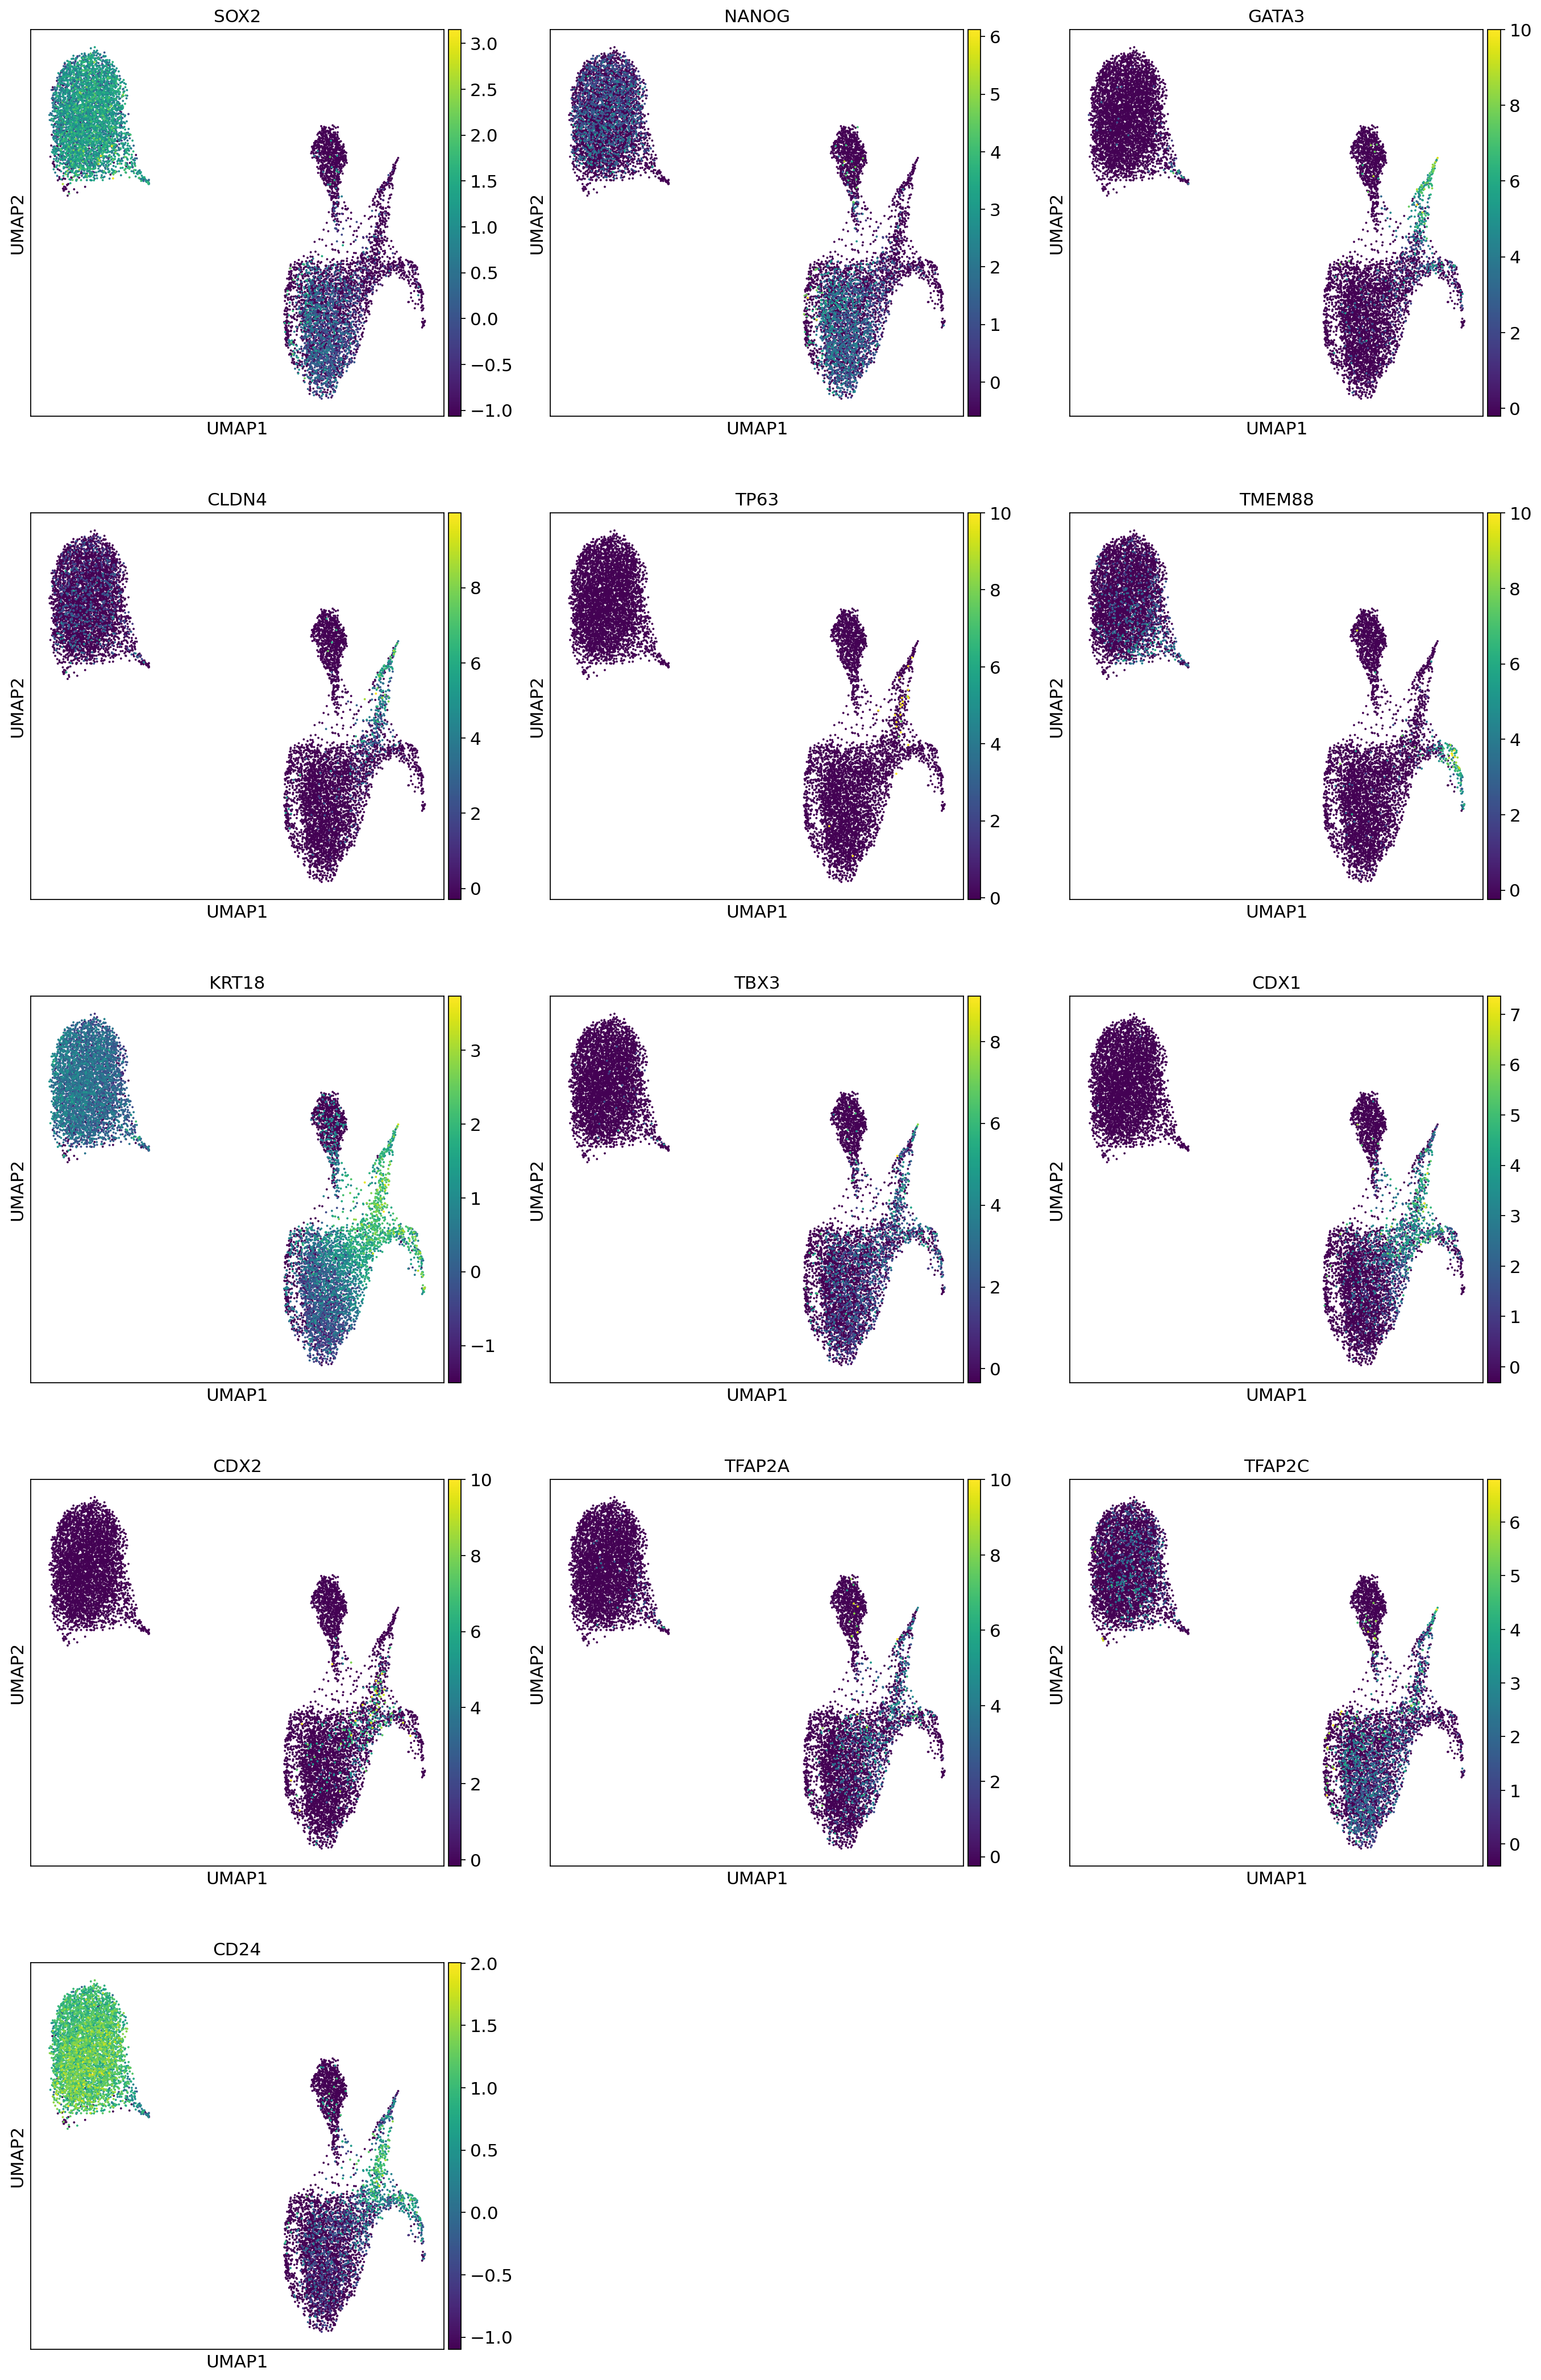

In [127]:
# ============================================
# 17. Marker gene visualization
# ============================================

#print all available adata.var_names

marker_genes = [
    "SOX2",  
    "NANOG",
    "GATA3", 
    "CLDN4",
    "TP63",
    "CGB",
    "TMEM88", 
    "KRT18",  
    "TBXT" 
    "SOX9",
    "TBX3",
    "CDX1",
    "CDX2",
    "TFAP2A",
    "TFAP2C", 
    "CD24", 
]

existing_markers = [
    g for g in marker_genes
    if g in adata.var_names
]

print(existing_markers)

# plot panel with 2 plots per row
sc.pl.umap(
    adata,
    color=existing_markers,
    ncols=3
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:42)


/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: 

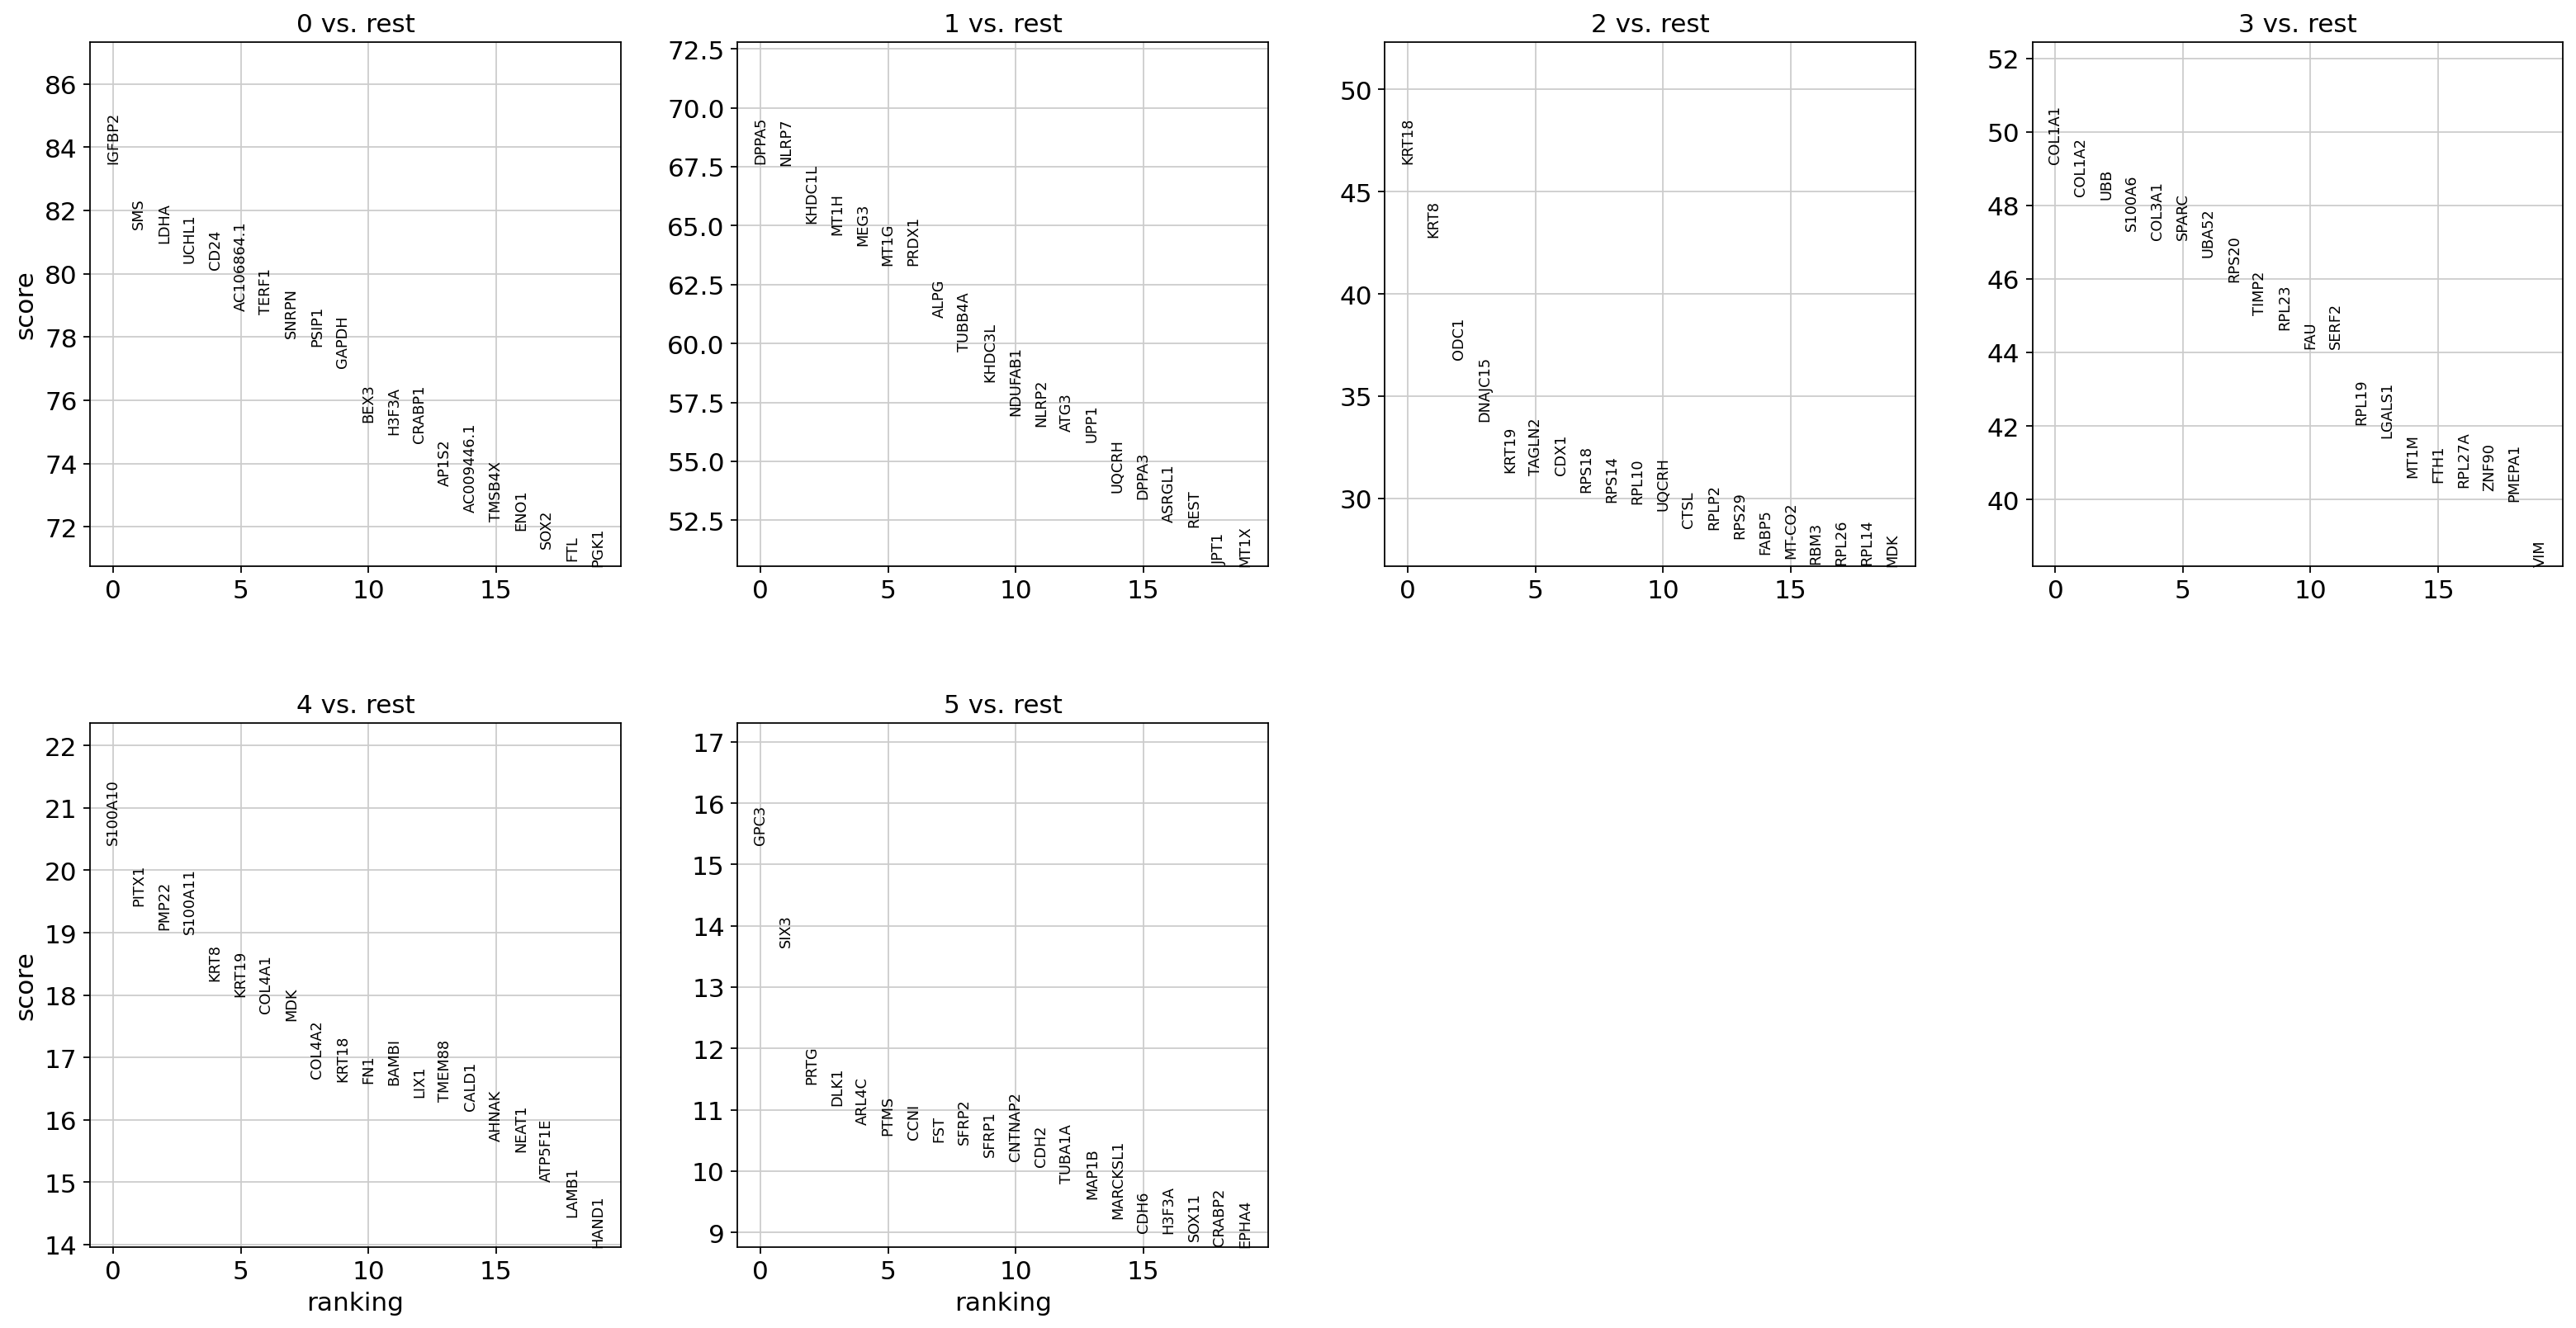

In [128]:


# ============================================
# 18. Find marker genes per cluster
# ============================================

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)

# Show top markers
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
    sharey=False
)



In [ ]:

# ============================================
# 19. Save processed object
# ============================================

adata.write("combined_scRNAseq.h5ad")

print("\nSaved combined_scRNAseq.h5ad")


# ============================================
# 20. Reload later
# ============================================

# adata = sc.read_h5ad("combined_scRNAseq.h5ad")

In [123]:

sdfs
sdfs



NameError: name 'sdfs' is not defined